# Quantum Simulation of Hamiltonians with Qiskit — Trotter, Suzuki & QDrift

**Quantum Computing Spring School 2026**
Session 12 · QSim laboratory

In [Session 4](../session-4-quantum-algorithms-qiskit/04_quantum_algorithms_qiskit.ipynb) we built our first genuine quantum *algorithms* — Deutsch–Jozsa and Grover — both built around oracles and interference. Today we turn to the problem quantum computers were originally invented for: **Hamiltonian simulation**, i.e. computing

$$
|\psi(t)\rangle = e^{-iHt}|\psi(0)\rangle
$$

for some Hamiltonian $H$ describing a physical system (a chain of spins, a molecule, a lattice model, ...). This is Feynman's 1982 observation and Lloyd's 1996 theorem made concrete: local Hamiltonians can be simulated *efficiently* on a quantum computer, using resources that scale polynomially in system size, even though the Hilbert space itself grows exponentially — a task with no known efficient classical algorithm in general.

**What we'll cover today:**

1. Setup and a quick recap
2. Why simulate Hamiltonians? The problem, and why it's hard classically
3. Product formulas: first- and second-order Trotter–Suzuki decompositions
4. QDrift: a randomized product formula
5. Case study 1 — simulating a spin chain and comparing product formulas head to head
6. Case study 2 — quantum dynamics across a phase transition
7. Wrap-up

**Scope note, as before:** everything today runs on classical simulators — `Statevector`, `StatevectorEstimator`, and exact matrix exponentials via `scipy.linalg.expm` for the small systems we can still diagonalise by hand as a "ground truth" to check our circuits against. No real hardware. The whole point of today's material is understanding what a quantum computer buys you once systems get too large for that classical ground truth to exist at all.

Each section has one or more **Exercises** — attempt them before running the solution cell underneath.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter, SuzukiTrotter, QDrift
from qiskit.primitives import StatevectorEstimator

np.set_printoptions(precision=4, suppress=True)

---

## 1. Setup and a quick recap

A one-cell refresher of the Qiskit objects we lean on today, most of them carried over from Sessions 3–4:

- `SparsePauliOp` — a Hamiltonian (or any observable) written as a weighted sum of Pauli strings, e.g. `SparsePauliOp.from_list([("XZ", 0.5), ("ZI", -1.0)])`.
- `Statevector(qc)` — the exact statevector of a (measurement-free) circuit.
- `Operator(qc)` — the exact unitary matrix implemented by a circuit — today's main tool for checking a simulation circuit against the truth.
- Qiskit's **little-endian** convention: qubit 0 is the rightmost character in a Pauli string or bitstring. It matters again today when we write down multi-qubit Hamiltonians by hand.

In [2]:
# sanity check: everything still imports and runs
H_demo = SparsePauliOp.from_list([("XZ", 0.5), ("ZI", -1.0)])
print(H_demo)
print("as a matrix:\n", H_demo.to_matrix())

SparsePauliOp(['XZ', 'ZI'],
              coeffs=[ 0.5+0.j, -1. +0.j])
as a matrix:
 [[-1. +0.j  0. +0.j  0.5+0.j  0. +0.j]
 [ 0. +0.j -1. +0.j  0. +0.j -0.5+0.j]
 [ 0.5+0.j  0. +0.j  1. +0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j  0. +0.j  1. +0.j]]


**A gotcha worth flagging immediately, because it will bite you today more than in previous sessions:** Qiskit's `PauliEvolutionGate` (introduced properly in section 3.4) caches the *exact* matrix exponential as its `.to_matrix()` value, regardless of which approximate synthesis method built its internal circuit. That means `Operator(qc)` on a circuit containing an *undecomposed* `PauliEvolutionGate` will silently give you the exact answer, not the Trotterized approximation you asked for — you have to call `qc.decompose()` first to see what was actually built. We'll hit this directly in section 3.4 and it's worth remembering for the rest of the notebook.

---

## 2. Why simulate Hamiltonians?

A quantum system of $n$ qubits (or spins, or any two-level components) lives in a Hilbert space of dimension $2^n$. Its state is a $2^n$-dimensional complex vector, and its Hamiltonian $H$ is a $2^n \times 2^n$ Hermitian matrix. To evolve a state forward in time exactly, classically, you need to build $e^{-iHt}$ — diagonalise or exponentiate a matrix whose size doubles with every additional particle. By $n \approx 50$ that matrix has more entries than there are atoms on Earth. **This exponential wall is not a limitation of today's computers or algorithms — it's believed to be fundamental**, and it's the reason large-scale simulation of quantum matter (new materials, catalysts, high-temperature superconductors, nuclear structure, ...) remains one of the most compute-starved problems in science.

A quantum computer sidesteps the wall in a specific and beautiful way. If $H$ is a sum of *local* terms —

$$
H = \sum_{k=1}^{L} H_k ,
$$

with each $H_k$ acting on only a few qubits at a time (as is true of essentially every physically realistic Hamiltonian: nearest-neighbour spin chains, molecular Hamiltonians in a local basis, lattice gauge theories, ...) — then Seth Lloyd showed in 1996 that $e^{-iHt}$ can be **approximated to any desired accuracy using a number of quantum gates that scales only polynomially** in $n$, $t$, and $L$. The state itself still lives in that exponentially large space, but you never have to write it down or manipulate it as a $2^n$-vector — the qubits themselves *are* the state, and gates that implement each local $H_k$ nudge that state along.

The catch, and the whole content of today's session: you generally **can't** apply $e^{-iHt}$ directly as a single gate, because the individual terms $H_k$ don't commute with each other. The rest of this notebook is about *product formulas* — ways of building a good circuit approximation to $e^{-iHt}$ out of gates for the individual (easy) $H_k$'s.

In [3]:
# The exponential wall, made concrete
for n in [4, 10, 20, 30, 50]:
    dim = 2 ** n
    bytes_needed = dim ** 2 * 16  # complex128 matrix, 16 bytes/entry
    print(f"n = {n:>3} qubits:  Hilbert space dim = 2^{n} = {dim:>15,}"
          f"   dense H matrix = {bytes_needed / 1e9:>14,.1f} GB")

n =   4 qubits:  Hilbert space dim = 2^4 =              16   dense H matrix =            0.0 GB
n =  10 qubits:  Hilbert space dim = 2^10 =           1,024   dense H matrix =            0.0 GB
n =  20 qubits:  Hilbert space dim = 2^20 =       1,048,576   dense H matrix =       17,592.2 GB
n =  30 qubits:  Hilbert space dim = 2^30 =   1,073,741,824   dense H matrix = 18,446,744,073.7 GB
n =  50 qubits:  Hilbert space dim = 2^50 = 1,125,899,906,842,624   dense H matrix = 20,282,409,603,651,671,687,168.0 GB


---

## 3. Product formulas: Trotter and Suzuki decompositions

### 3.1 The problem with non-commuting terms

If $H = A + B$ and $[A, B] = AB - BA = 0$, then $e^{-i(A+B)t} = e^{-iAt}e^{-iBt}$ exactly — ordinary exponent rules apply. But if $A$ and $B$ don't commute (the generic, interesting case), this factorisation is simply **false**. The Baker–Campbell–Hausdorff (BCH) formula tells us exactly how false:

$$
e^{-iAt}e^{-iBt} = \exp\!\left(-i(A+B)t - \tfrac{1}{2}[A,B]t^2 + O(t^3)\right).
$$

The leading error term is $O(t^2)$, proportional to the size of the commutator $[A,B]$ — the more $A$ and $B$ "disagree," the worse the single-step approximation. The idea behind every product formula in this section is to tame this error by **taking many small time steps** rather than one big one, since the error per step shrinks faster than the number of steps grows.

### 3.2 First-order Trotter (Lie–Trotter)

The simplest product formula, the **Lie–Trotter formula**, splits the evolution into $n$ small steps of size $t/n$ and alternates $A$ and $B$ within each step:

$$
e^{-i(A+B)t} \;\approx\; \Big(e^{-iAt/n}\,e^{-iBt/n}\Big)^{n} \;\equiv\; U_1(t, n).
$$

From the BCH bound above, each of the $n$ steps has an $O((t/n)^2)$ error, and these errors accumulate (at worst) additively over $n$ steps, giving a **total error that scales as $O(t^2/n)$** — it shrinks linearly in the number of Trotter steps $n$. This is called **first-order** Trotterization.

Let's see this directly, by hand with NumPy, on the simplest possible non-commuting example: a single qubit with $H = aX + bZ$ (the two Pauli terms don't commute, so this already captures the essential difficulty).

In [4]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

a, b, t = 1.0, 0.7, 1.3
H = a * X + b * Z
U_exact = expm(-1j * t * H)

print("[X, Z] =\n", X @ Z - Z @ X, "\n(nonzero -- these terms genuinely don't commute)")


def trotter1(n):
    """First-order Lie-Trotter approximation to exp(-i H t), n steps."""
    dt = t / n
    step = expm(-1j * dt * a * X) @ expm(-1j * dt * b * Z)
    U = np.eye(2, dtype=complex)
    for _ in range(n):
        U = step @ U
    return U


for n in [1, 2, 4, 8]:
    err = np.linalg.norm(trotter1(n) - U_exact, ord=2)
    print(f"n = {n:>2} steps:  ||U_trotter1 - U_exact|| = {err:.4f}")

[X, Z] =
 [[ 0.+0.j -2.+0.j]
 [ 2.+0.j  0.+0.j]] 
(nonzero -- these terms genuinely don't commute)
n =  1 steps:  ||U_trotter1 - U_exact|| = 0.8912
n =  2 steps:  ||U_trotter1 - U_exact|| = 0.3915
n =  4 steps:  ||U_trotter1 - U_exact|| = 0.1887
n =  8 steps:  ||U_trotter1 - U_exact|| = 0.0935


**Exercise:** before running the cell below, predict what should happen to the error if you *double* $n$ again each time (to 16, 32, 64). Given the $O(t^2/n)$ scaling, roughly what factor should the error shrink by each time you double $n$? Then run the cell and check a log-log plot's slope against your prediction.

measured slope (expect close to -1): -1.0332504924970758


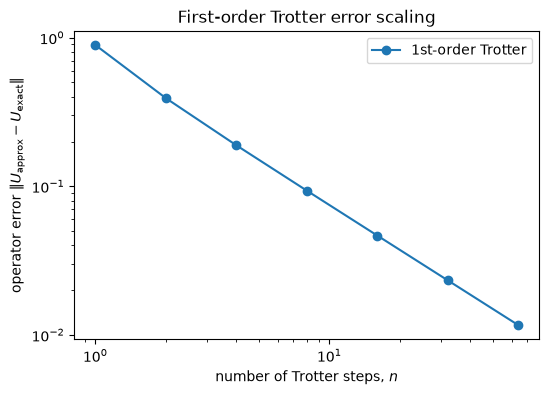

In [5]:
n_list = [1, 2, 4, 8, 16, 32, 64]
err1 = [np.linalg.norm(trotter1(n) - U_exact, ord=2) for n in n_list]

slope1 = np.polyfit(np.log(n_list), np.log(err1), 1)[0]
print("measured slope (expect close to -1):", slope1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_list, err1, "o-", label="1st-order Trotter")
ax.set_xlabel("number of Trotter steps, $n$")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title("First-order Trotter error scaling")
ax.legend()
plt.show()

A slope of $-1$ on a log-log plot means error $\propto n^{-1}$ — exactly the $O(t^2/n)$ scaling predicted above. Doubling $n$ halves the error, consistently.

### 3.3 Second-order Trotter–Suzuki (Strang splitting)

We can do much better with the same *kind* of building blocks, just arranged more cleverly. The **second-order Suzuki formula** (also called Strang splitting) symmetrises each step:

$$
e^{-i(A+B)t} \;\approx\; \Big(e^{-iAt/2n}\,e^{-iBt/n}\,e^{-iAt/2n}\Big)^{n} \;\equiv\; U_2(t, n).
$$

Each step now costs one extra half-sized $A$-exponential, but the symmetry causes the $O(t^2)$ error term from BCH to **cancel exactly** between the forward and backward halves of the sandwich, leaving a leading error of $O(t^3)$ per step and a **total error scaling as $O(t^3/n^2)$** — quadratically better in $n$ than first order, at roughly double the gate cost per step.

measured slope (expect close to -2): -2.0349858072030185


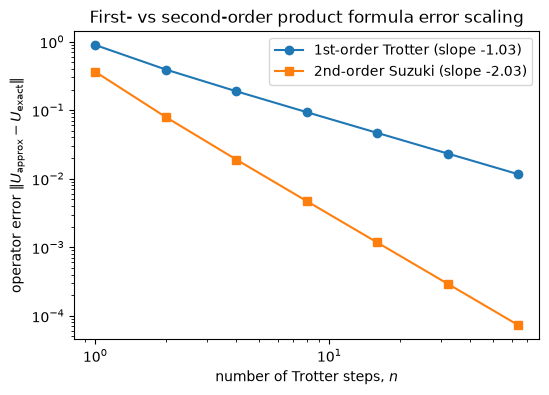

In [6]:
def trotter2(n):
    """Second-order (Strang / symmetric) Trotter approximation, n steps."""
    dt = t / n
    step = (
        expm(-1j * dt / 2 * a * X)
        @ expm(-1j * dt * b * Z)
        @ expm(-1j * dt / 2 * a * X)
    )
    U = np.eye(2, dtype=complex)
    for _ in range(n):
        U = step @ U
    return U


err2 = [np.linalg.norm(trotter2(n) - U_exact, ord=2) for n in n_list]
slope2 = np.polyfit(np.log(n_list), np.log(err2), 1)[0]
print("measured slope (expect close to -2):", slope2)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_list, err1, "o-", label="1st-order Trotter (slope %.2f)" % slope1)
ax.loglog(n_list, err2, "s-", label="2nd-order Suzuki (slope %.2f)" % slope2)
ax.set_xlabel("number of Trotter steps, $n$")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title("First- vs second-order product formula error scaling")
ax.legend()
plt.show()

The second-order curve should fall off *much* faster — roughly a factor of 4 for every doubling of $n$, instead of a factor of 2. This is the standard trade-off in Hamiltonian simulation: higher-order formulas cost more gates per step but need far fewer steps for the same target accuracy, and for demanding simulations the second-order (or even higher-order) formula almost always wins overall.

**Exercise:** at what $n$ does the first-order error finally drop *below* the second-order error at $n=1$ (i.e. below `err2[0]`)? Find it by inspecting `err1` and `n_list`, or by writing a short loop. This is a concrete illustration of "more gates per step but far fewer steps" actually paying off.

In [7]:
target = err2[0]
n_needed = next(n for n, e in zip(n_list, err1) if e < target)
print(f"2nd-order with n=1 already beats 1st-order until n={n_needed} steps "
      f"(err2[0]={target:.4f}, err1 at n={n_needed} is {err1[n_list.index(n_needed)]:.4f})")

2nd-order with n=1 already beats 1st-order until n=4 steps (err2[0]=0.3620, err1 at n=4 is 0.1887)


### 3.4 Building product formulas in Qiskit

Qiskit provides both formulas (and more — arbitrary even orders via recursive Suzuki formulas) ready-made, via `qiskit.synthesis.LieTrotter` and `qiskit.synthesis.SuzukiTrotter`, used as the `synthesis` argument of a `PauliEvolutionGate`. Let's rebuild the toy example above as an actual quantum circuit and confirm it matches our by-hand NumPy version.

In [8]:
H_toy = SparsePauliOp.from_list([("X", a), ("Z", b)])

reps = 8
gate1 = PauliEvolutionGate(H_toy, time=t, synthesis=LieTrotter(reps=reps))
qc1 = QuantumCircuit(1)
qc1.append(gate1, [0])
print(qc1.decompose(reps=2).draw(fold=-1))

global phase: 5.3732
   ┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐┌────────────┐┌───────────┐
q: ┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├┤ R(0.325,0) ├┤ P(0.2275) ├
   └────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘└────────────┘└───────────┘


Now the gotcha flagged in section 1, demonstrated directly:

In [9]:
# DON'T do this to check the approximation -- to_matrix() on an
# un-decomposed PauliEvolutionGate always returns the EXACT exponential:
print("Operator(qc1) directly -- looks exact, this is misleading:")
print(np.linalg.norm(Operator(qc1).data - U_exact, ord=2))

# DO this instead -- decompose first, so Operator() actually walks
# through the gates the synthesis method built:
print("\nOperator(qc1.decompose()) -- the real Trotter approximation:")
print(np.linalg.norm(Operator(qc1.decompose(reps=3)).data - U_exact, ord=2))
print("(compare to our by-hand trotter1(8) result:", err1[n_list.index(8)], ")")

Operator(qc1) directly -- looks exact, this is misleading:
4.599595552540379e-16

Operator(qc1.decompose()) -- the real Trotter approximation:
0.09346577977796122
(compare to our by-hand trotter1(8) result: 0.0934657797779578 )


The decomposed-circuit error should match our hand-rolled `trotter1(8)` result closely (small differences can come from how Qiskit orders terms internally). From here on, **always decompose before measuring an approximation error** — we'll build a small helper to make this automatic.

In [10]:
def circuit_error(H, t, synthesis, U_exact):
    """Operator-norm error between a PauliEvolutionGate circuit
    (built with the given synthesis method) and the exact evolution."""
    n_qubits = H.num_qubits
    gate = PauliEvolutionGate(H, time=t, synthesis=synthesis)
    qc = QuantumCircuit(n_qubits)
    qc.append(gate, range(n_qubits))
    U_approx = Operator(qc.decompose(reps=3)).data
    return np.linalg.norm(U_approx - U_exact, ord=2)


print(circuit_error(H_toy, t, LieTrotter(reps=8), U_exact))
print(circuit_error(H_toy, t, SuzukiTrotter(order=2, reps=8), U_exact))

0.09346577977796122
0.004709702698593865


---

## 4. QDrift: a randomized product formula

Trotter and Suzuki formulas apply *every* term $H_k$ at *every* step, in a fixed order. When a Hamiltonian has a large number of terms $L$ (a densely-connected spin model, a molecular Hamiltonian in second quantization, ...), that per-step cost grows linearly in $L$ — expensive. **QDrift**, introduced by Campbell (2019), takes a completely different, randomized approach: at each step, sample *one* term $H_k$ from the sum (with probability proportional to its coefficient's size) and apply *only* that term, but for a correspondingly longer effective time.

Concretely, write $H = \sum_k h_k P_k$ with each $P_k$ a Pauli string and $h_k > 0$ WLOG, and let $\lambda = \sum_k h_k$. One QDrift step:

1. Sample an index $k$ with probability $h_k / \lambda$.
2. Apply $e^{-i\,\mathrm{sign}(h_k)\,\lambda t/N\,P_k}$, where $N$ is the total number of samples (steps) and $t$ is the total simulation time.

Repeat $N$ times. The remarkable result is that the expected error of this scheme is $O(\lambda^2 t^2 / N)$ — **independent of the number of terms $L$** — whereas a Trotter step touches all $L$ terms every time. For Hamiltonians with many terms and a fixed error budget, QDrift can need far fewer *total gates* than Trotter, at the cost of being a probabilistic algorithm (each run implements a slightly different, randomly-chosen circuit) rather than a deterministic one.

Qiskit provides this as `qiskit.synthesis.QDrift`, with the same `PauliEvolutionGate` interface as before.

measured QDrift slope (expect close to -0.5): -0.37770663409205185


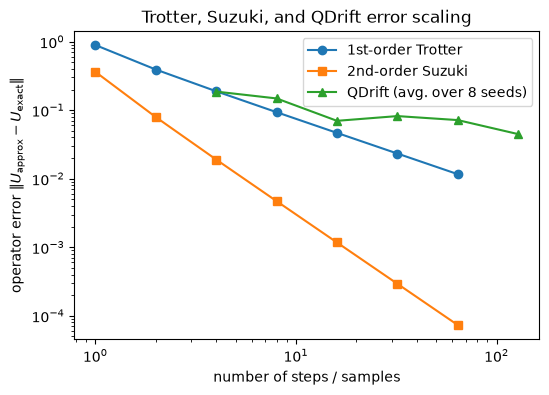

In [11]:
def circuit_error_avg(H, t, synthesis_factory, U_exact, n_seeds=8):
    """Average operator error over several random QDrift instances."""
    errs = [circuit_error(H, t, synthesis_factory(seed), U_exact) for seed in range(n_seeds)]
    return np.mean(errs)


reps_q = [4, 8, 16, 32, 64, 128]
errq = [
    circuit_error_avg(H_toy, t, lambda s, r=r: QDrift(reps=r, seed=s), U_exact)
    for r in reps_q
]
slopeq = np.polyfit(np.log(reps_q), np.log(errq), 1)[0]
print("measured QDrift slope (expect close to -0.5):", slopeq)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n_list, err1, "o-", label="1st-order Trotter")
ax.loglog(n_list, err2, "s-", label="2nd-order Suzuki")
ax.loglog(reps_q, errq, "^-", label="QDrift (avg. over 8 seeds)")
ax.set_xlabel("number of steps / samples")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title("Trotter, Suzuki, and QDrift error scaling")
ax.legend()
plt.show()

QDrift's $O(1/\sqrt{N})$ scaling is *worse per step* than either Trotter formula on this 2-term toy Hamiltonian — that's expected and not a fair fight yet, because QDrift's real advantage is in the number of terms $L$, not the step-scaling exponent, and $L=2$ here is as small as it gets. We'll get a fairer comparison in the next section with a Hamiltonian that has many more terms.

**Exercise:** QDrift is a *randomized* algorithm — a different seed gives a genuinely different circuit, and hence a different error, every time. Recompute the error-vs-$N$ curve with a completely different, non-overlapping batch of seeds (say 20–219 instead of 0–7) and check that the $N^{-1/2}$ trend survives even though the individual error values will differ from the ones above. This is worth doing explicitly once: unlike Trotter/Suzuki (deterministic — rerunning gives identical numbers), QDrift's guarantee is a *statistical* one about the average error over many random instances, not a promise about any single run.

In [12]:
reps_q_fresh = [4, 8, 16, 32, 64, 128]
errq_fresh = [
    circuit_error_avg(H_toy, t, lambda s, r=r: QDrift(reps=r, seed=s), U_exact, n_seeds=12)
    for r in reps_q_fresh
]
# note: circuit_error_avg's seeds start at 0 by construction (see its definition above);
# here we shift the seed range explicitly to get a genuinely independent batch
def circuit_error_avg_seeded(H, t, reps, U_exact, seed_start, n_seeds=12):
    errs = [circuit_error(H, t, QDrift(reps=reps, seed=s), U_exact)
            for s in range(seed_start, seed_start + n_seeds)]
    return np.mean(errs)

errq_fresh = [circuit_error_avg_seeded(H_toy, t, r, U_exact, seed_start=1000) for r in reps_q_fresh]
slopeq_fresh = np.polyfit(np.log(reps_q_fresh), np.log(errq_fresh), 1)[0]
print("original batch (seeds 0-7):   ", [f"{e:.4f}" for e in errq])
print("fresh batch (seeds 1000-1011):", [f"{e:.4f}" for e in errq_fresh])
print("slope from the fresh batch (still expect close to -0.5):", slopeq_fresh)

original batch (seeds 0-7):    ['0.1867', '0.1483', '0.0699', '0.0820', '0.0717', '0.0448']
fresh batch (seeds 1000-1011): ['0.2300', '0.1655', '0.1112', '0.0852', '0.0495', '0.0363']
slope from the fresh batch (still expect close to -0.5): -0.5406680216981318


---

## 5. Case study 1: simulating a spin chain

### 5.1 The transverse-field Ising model (TFIM)

Our test Hamiltonian for the rest of the notebook is the **transverse-field Ising model** on a chain of $n$ spins — one of the most-studied models in condensed matter physics, and small enough to simulate exactly (for a few qubits) so we always have ground truth to check against:

$$
H = -J \sum_{i=0}^{n-2} Z_i Z_{i+1} \;-\; h \sum_{i=0}^{n-1} X_i .
$$

$J$ sets the strength of a nearest-neighbour ferromagnetic coupling (favouring aligned spins along $Z$), and $h$ is a uniform transverse magnetic field (favouring alignment along $X$). This model has exactly $2n - 1$ Pauli terms — many more than our toy example, and, importantly, they **don't all commute with each other** (the $ZZ$ and $X$ terms don't commute), which is exactly the regime product formulas are built for.

In [13]:
def tfim_hamiltonian(n, J, h):
    """Build the TFIM Hamiltonian -J sum ZZ - h sum X as a SparsePauliOp.
    Uses Qiskit's little-endian convention (index 0 = rightmost character)."""
    terms = []
    for i in range(n - 1):
        label = ["I"] * n
        label[i], label[i + 1] = "Z", "Z"
        terms.append(("".join(label)[::-1], -J))
    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        terms.append(("".join(label)[::-1], -h))
    return SparsePauliOp.from_list(terms)


N, J, h = 4, 1.0, 0.5
H_tfim = tfim_hamiltonian(N, J, h)
print(H_tfim)
print(f"\nnumber of terms: {len(H_tfim)}   (2N - 1 = {2 * N - 1})")

SparsePauliOp(['IIZZ', 'IZZI', 'ZZII', 'IIIX', 'IIXI', 'IXII', 'XIII'],
              coeffs=[-1. +0.j, -1. +0.j, -1. +0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j])

number of terms: 7   (2N - 1 = 7)


### 5.2 Comparing product formulas head to head

For $N=4$ the Hilbert space is only $2^4 = 16$-dimensional, so we can still build the *exact* evolution operator classically with `scipy.linalg.expm` — our ground truth, exactly as in section 3 — and see how each simulation method approaches it as we increase the step budget.

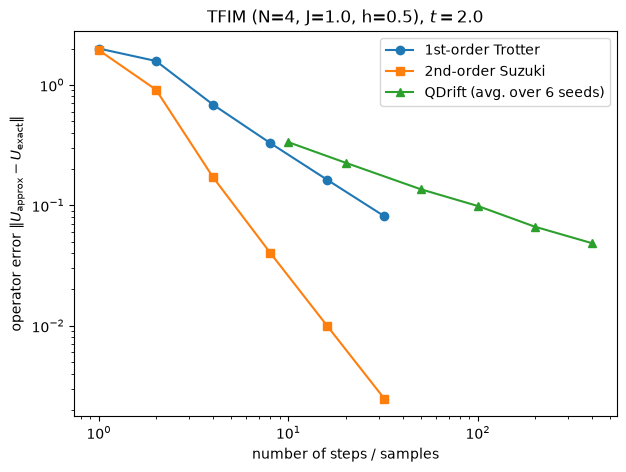

1st-order slope: -0.9713000175171977
2nd-order slope: -1.9898430732834926


In [14]:
t_sim = 2.0
H_mat = H_tfim.to_matrix()
U_exact_tfim = expm(-1j * t_sim * H_mat)

n_list_tfim = [1, 2, 4, 8, 16, 32]
err1_tfim = [circuit_error(H_tfim, t_sim, LieTrotter(reps=r), U_exact_tfim) for r in n_list_tfim]
err2_tfim = [circuit_error(H_tfim, t_sim, SuzukiTrotter(order=2, reps=r), U_exact_tfim) for r in n_list_tfim]

reps_q_tfim = [10, 20, 50, 100, 200, 400]
errq_tfim = [
    circuit_error_avg(H_tfim, t_sim, lambda s, r=r: QDrift(reps=r, seed=s), U_exact_tfim, n_seeds=6)
    for r in reps_q_tfim
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(n_list_tfim, err1_tfim, "o-", label="1st-order Trotter")
ax.loglog(n_list_tfim, err2_tfim, "s-", label="2nd-order Suzuki")
ax.loglog(reps_q_tfim, errq_tfim, "^-", label="QDrift (avg. over 6 seeds)")
ax.set_xlabel("number of steps / samples")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title(f"TFIM (N={N}, J={J}, h={h}), $t={t_sim}$")
ax.legend()
plt.show()

print("1st-order slope:", np.polyfit(np.log(n_list_tfim), np.log(err1_tfim), 1)[0])
print("2nd-order slope:", np.polyfit(np.log(n_list_tfim), np.log(err2_tfim), 1)[0])

Same qualitative picture as the toy example — first order scales as $n^{-1}$, second order as $n^{-2}$ — now on a genuine multi-term, non-commuting spin Hamiltonian.

Step count isn't the full story, though: each Suzuki step costs roughly twice the two-qubit gates of a Trotter step, and each QDrift "step" is a single Pauli-string exponential regardless of $L$. What actually matters for running on real hardware is **total gate count for a target accuracy**, so let's compare that directly.

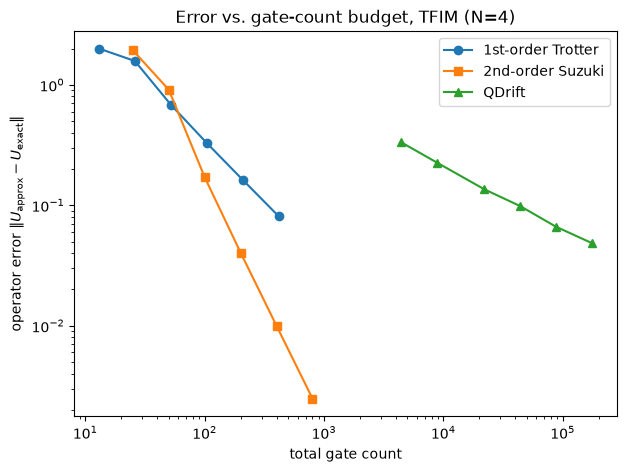

In [15]:
def gate_count(H, t, synthesis):
    n_qubits = H.num_qubits
    gate = PauliEvolutionGate(H, time=t, synthesis=synthesis)
    qc = QuantumCircuit(n_qubits)
    qc.append(gate, range(n_qubits))
    return qc.decompose(reps=3).size()


gc1 = [gate_count(H_tfim, t_sim, LieTrotter(reps=r)) for r in n_list_tfim]
gc2 = [gate_count(H_tfim, t_sim, SuzukiTrotter(order=2, reps=r)) for r in n_list_tfim]
gcq = [gate_count(H_tfim, t_sim, QDrift(reps=r, seed=0)) for r in reps_q_tfim]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(gc1, err1_tfim, "o-", label="1st-order Trotter")
ax.loglog(gc2, err2_tfim, "s-", label="2nd-order Suzuki")
ax.loglog(gcq, errq_tfim, "^-", label="QDrift")
ax.set_xlabel("total gate count")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title(f"Error vs. gate-count budget, TFIM (N={N})")
ax.legend()
plt.show()

For a *fixed error target*, read this plot horizontally: second-order Suzuki reaches any given accuracy with dramatically fewer total gates than first-order Trotter on this model — the extra cost per step is worth it. QDrift's crossover point (where it starts beating Trotter on a *gate-count* basis) moves further left as the number of Hamiltonian terms $L$ grows; at $L = 2N-1 = 7$ terms it's still not competitive with second-order Suzuki here, but the gap narrows quickly for denser Hamiltonians (try increasing `N`, which increases $L$, as an exercise).

**Exercise:** repeat the comparison above (error vs. gate count) for a stronger field, `h = J = 1.0` (the critical point — see section 6). Does the qualitative ranking of the three methods change?

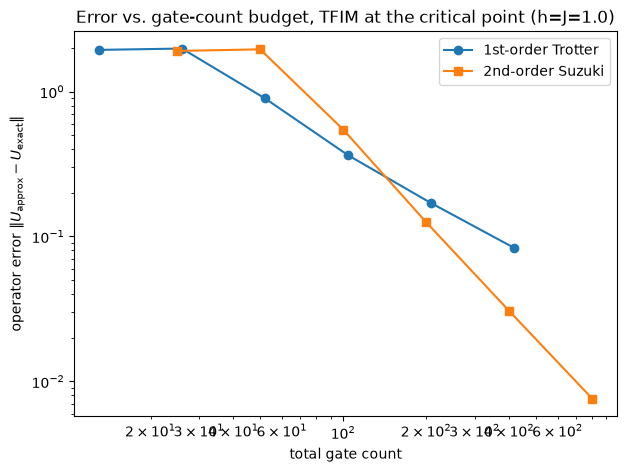

In [16]:
H_tfim_crit = tfim_hamiltonian(N, J, 1.0)
H_mat_crit = H_tfim_crit.to_matrix()
U_exact_crit = expm(-1j * t_sim * H_mat_crit)

err1_crit = [circuit_error(H_tfim_crit, t_sim, LieTrotter(reps=r), U_exact_crit) for r in n_list_tfim]
err2_crit = [circuit_error(H_tfim_crit, t_sim, SuzukiTrotter(order=2, reps=r), U_exact_crit) for r in n_list_tfim]
gc1_crit = [gate_count(H_tfim_crit, t_sim, LieTrotter(reps=r)) for r in n_list_tfim]
gc2_crit = [gate_count(H_tfim_crit, t_sim, SuzukiTrotter(order=2, reps=r)) for r in n_list_tfim]

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(gc1_crit, err1_crit, "o-", label="1st-order Trotter")
ax.loglog(gc2_crit, err2_crit, "s-", label="2nd-order Suzuki")
ax.set_xlabel("total gate count")
ax.set_ylabel(r"operator error $\|U_{\rm approx} - U_{\rm exact}\|$")
ax.set_title(f"Error vs. gate-count budget, TFIM at the critical point (h=J={J})")
ax.legend()
plt.show()

---

## 6. Case study 2: quantum dynamics across a phase transition

### 6.1 The TFIM's quantum phase transition

The TFIM is famous because, in the limit of an infinitely long chain, it has an exact **quantum phase transition** at $h = J$:

- For $h < J$ (coupling dominates), the ground state is (spontaneously-symmetry-broken) **ferromagnetically ordered**: spins prefer to align, and a local order parameter like $\langle Z_i \rangle$ stays nonzero.
- For $h > J$ (field dominates), the ground state is **paramagnetic**: the field aligns every spin along $X$ and the $Z$-order parameter vanishes.
- Exactly at $h = J$, the energy gap between ground and first excited state closes (in the infinite chain limit) and the system is **critical** — scale-invariant, with power-law-decaying correlations instead of either ordered or short-ranged behaviour.

On our small, finite chains this transition is *rounded off* into a smooth crossover rather than a sharp transition (genuine non-analyticities only appear strictly at infinite system size) — but even a handful of qubits already shows a clear, sharp-ening signature of it, which is exactly what we'll go looking for using the simulation tools built in sections 3–5.

### 6.2 A dynamical probe: quenching a fully-ordered state

Rather than computing ground states directly, we'll use a **quench**: prepare the system in a simple, far-from-equilibrium initial state, then let it evolve under a *fixed* TFIM Hamiltonian and watch what happens. This is exactly the kind of experiment real quantum simulators run, and it's a natural fit for everything we've built today — the evolution is done entirely with the Trotter/Suzuki circuits from section 5.

Our initial state is $|00\cdots0\rangle$ — every spin aligned along $+Z$, the exact ground state of the $h=0$ (pure Ising, no field) Hamiltonian, and about as far from an $X$-eigenstate as a state can be. We then evolve it under the TFIM at some field strength $h$, and track the **average magnetization**

$$
\langle Z\rangle(t) = \frac{1}{n}\sum_{i} \langle \psi(t)|Z_i|\psi(t)\rangle ,
$$

using `StatevectorEstimator` with a `SparsePauliOp` observable, exactly as in Session 3's Estimator section.

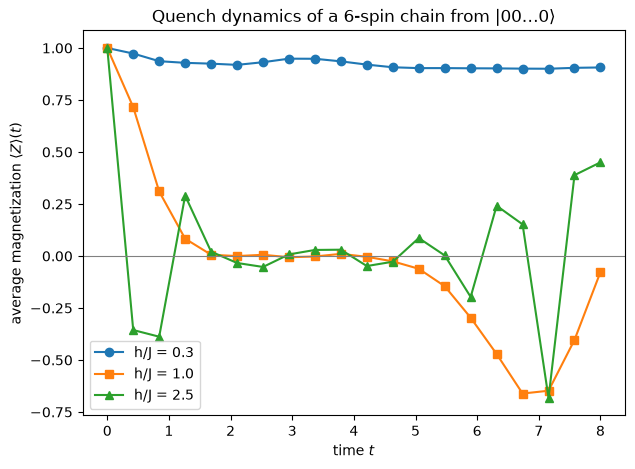

In [17]:
def avg_z_observable(n):
    return SparsePauliOp.from_list(
        [("".join("Z" if k == i else "I" for k in range(n))[::-1], 1.0 / n) for i in range(n)]
    )


def quench_circuit(H, t, order=2, reps_per_unit_time=6):
    """Trotterized evolution of |0...0> under H for time t."""
    n_qubits = H.num_qubits
    reps = max(1, int(np.ceil(reps_per_unit_time * max(t, 1e-9))))
    qc = QuantumCircuit(n_qubits)
    gate = PauliEvolutionGate(H, time=t, synthesis=SuzukiTrotter(order=order, reps=reps))
    qc.append(gate, range(n_qubits))
    return qc


N2, J2 = 6, 1.0
obs_avgz = avg_z_observable(N2)
estimator = StatevectorEstimator()
times = np.linspace(0, 8, 20)

fig, ax = plt.subplots(figsize=(7, 5))
for h_val, style in zip([0.3, 1.0, 2.5], ["o-", "s-", "^-"]):
    H_h = tfim_hamiltonian(N2, J2, h_val)
    circuits = [quench_circuit(H_h, t) for t in times]
    job = estimator.run([(qc, obs_avgz) for qc in circuits])
    vals = [res.data.evs for res in job.result()]
    ax.plot(times, vals, style, label=f"h/J = {h_val}")

ax.axhline(0, color="grey", linewidth=0.8)
ax.set_xlabel("time $t$")
ax.set_ylabel(r"average magnetization $\langle Z\rangle(t)$")
ax.set_title(f"Quench dynamics of a {N2}-spin chain from $|00\\ldots0\\rangle$")
ax.legend()
plt.show()

Deep in the ferromagnetic phase ($h \ll J$) the magnetization barely moves — the initial state is close to the true ground state, so there's very little to evolve into. Near and beyond the critical field the transverse field scrambles the initial order almost immediately, and the magnetization collapses toward zero with fast oscillations. That qualitative split — "order survives the quench" vs. "order is destroyed by the quench" — is itself a dynamical fingerprint of the equilibrium phase transition, even though we never computed a single ground state.

**Sanity check against exact evolution**, for one value of $h$, confirming the Trotter circuit is doing its job:

In [18]:
h_check = 1.0
H_check = tfim_hamiltonian(N2, J2, h_check)
H_check_mat = H_check.to_matrix()
psi0 = Statevector.from_label("0" * N2)

exact_vals = [Statevector(expm(-1j * t * H_check_mat) @ psi0.data).expectation_value(obs_avgz).real for t in times]
trotter_vals = [
    Statevector(quench_circuit(H_check, t)).expectation_value(obs_avgz).real for t in times
]

print("max |exact - trotter| over the whole time series:",
      np.max(np.abs(np.array(exact_vals) - np.array(trotter_vals))))

max |exact - trotter| over the whole time series: 6.439293542825908e-15


### 6.3 Order-parameter melting: scanning across the transition

Now the payoff: repeat the quench for many values of $h$, and for each one average $|\langle Z\rangle(t)|$ over the *second half* of the time window (to smooth out the oscillations and get a representative "how much order survived" number). Plotting that against $h/J$ should reveal the ordered-to-disordered crossover directly.

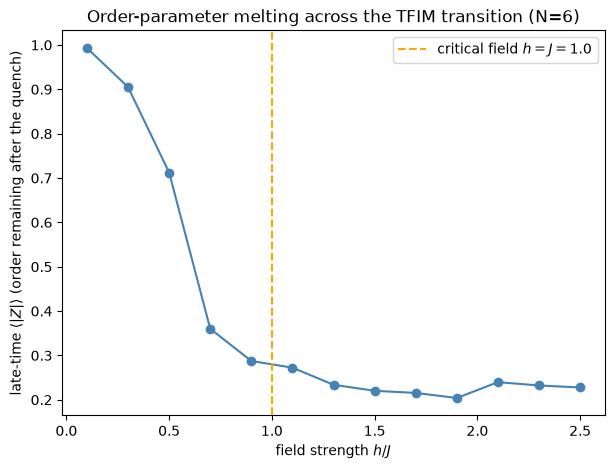

In [19]:
h_scan = np.linspace(0.1, 2.5, 13)
late_avg = []

for h_val in h_scan:
    H_h = tfim_hamiltonian(N2, J2, h_val)
    vals = np.array([
        Statevector(quench_circuit(H_h, t)).expectation_value(obs_avgz).real for t in times
    ])
    late_avg.append(np.mean(np.abs(vals[len(vals) // 2:])))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h_scan, late_avg, "o-", color="steelblue")
ax.axvline(J2, color="orange", linestyle="--", label=f"critical field $h=J={J2}$")
ax.set_xlabel("field strength $h/J$")
ax.set_ylabel(r"late-time $\langle |Z| \rangle$ (order remaining after the quench)")
ax.set_title(f"Order-parameter melting across the TFIM transition (N={N2})")
ax.legend()
plt.show()

The curve should fall steeply as $h$ crosses $J$ and flatten out into a low, roughly constant plateau beyond it — a finite-size echo of the sharp phase transition that only becomes perfectly sharp as $n \to \infty$. This is exactly the kind of experiment being run today on real superconducting-qubit and trapped-ion quantum simulators to study quantum matter that has no efficient classical description — you've just built a (small, classically-checkable) version of it yourself.

**Exercise:** repeat the scan with a larger chain, `N2 = 8` (still small enough to keep the exact-diagonalisation cross-check from section 6.2 tractable, if you want to re-run it too). Does the crossover around $h/J=1$ look sharper or smoother than the $N=6$ result? Which do you expect, given that the transition is only exactly sharp at $n\to\infty$?

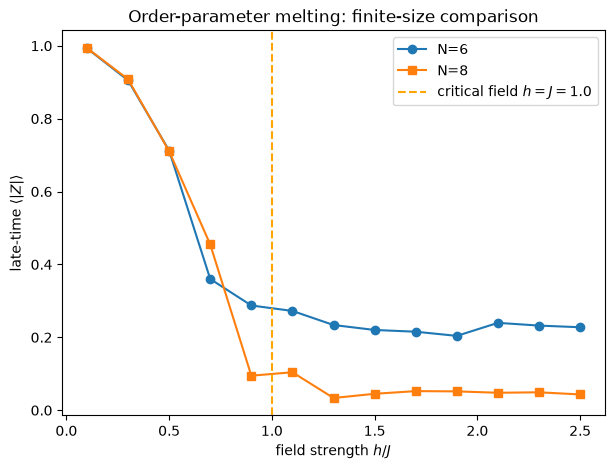

In [20]:
N3 = 8
obs_avgz_3 = avg_z_observable(N3)
late_avg_3 = []

for h_val in h_scan:
    H_h = tfim_hamiltonian(N3, J2, h_val)
    vals = np.array([
        Statevector(quench_circuit(H_h, t)).expectation_value(obs_avgz_3).real for t in times
    ])
    late_avg_3.append(np.mean(np.abs(vals[len(vals) // 2:])))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(h_scan, late_avg, "o-", label=f"N={N2}")
ax.plot(h_scan, late_avg_3, "s-", label=f"N={N3}")
ax.axvline(J2, color="orange", linestyle="--", label=f"critical field $h=J={J2}$")
ax.set_xlabel("field strength $h/J$")
ax.set_ylabel(r"late-time $\langle |Z| \rangle$")
ax.set_title("Order-parameter melting: finite-size comparison")
ax.legend()
plt.show()

---

## 7. Wrap-up

**What we covered:**

- **Hamiltonian simulation** — computing $e^{-iHt}|\psi\rangle$ — is efficient on a quantum computer for local Hamiltonians (Lloyd, 1996), even though the underlying Hilbert space, and hence any *classical* representation of the state, grows exponentially with system size.
- Because the terms making up a realistic Hamiltonian generally don't commute, $e^{-iHt}$ can't be built directly from gates for the individual terms — **product formulas** approximate it by chopping the evolution into many small steps.
- **First-order Trotter (Lie–Trotter):** alternate $e^{-iAt/n}e^{-iBt/n}$, error $O(t^2/n)$.
- **Second-order Suzuki (Strang splitting):** symmetrise as $e^{-iAt/2n}e^{-iBt/n}e^{-iAt/2n}$, error $O(t^3/n^2)$ — quadratically better in step count, usually worth the extra per-step cost.
- **QDrift:** randomly sample one Hamiltonian term per step, weighted by its coefficient; error $O(\lambda^2t^2/N)$, notably *independent of the number of terms* — a good fit for Hamiltonians with many terms, at the cost of being a randomized algorithm.
- We validated all three methods on a **transverse-field Ising chain**, comparing both step count and total gate count against exact classical diagonalisation (available only because our chains were small enough to still diagonalise!).
- A **quench across the TFIM's quantum phase transition** showed a genuine physical signature — order surviving vs. being destroyed by the field — entirely from the same Trotter/Suzuki circuits, no ground-state computation required.

**Common pitfalls to watch for:**

- Calling `Operator(qc)` (or `Statevector(qc)`, which is fine — see below) on a circuit containing an **un-decomposed** `PauliEvolutionGate` and expecting to see Trotter error: `.to_matrix()` on that gate returns the *exact* exponential by default. `Statevector(qc)` is safe because it *runs* the circuit's decomposition rather than reading a cached matrix — the danger is specifically `Operator(qc)` (and anything else that reads `.to_matrix()`) without decomposing first.
- Forgetting that product-formula error accumulates with **both** the number of terms and the simulated time $t$ — always check error scaling at the $t$ you actually care about, not just at $t=1$.
- Comparing methods by **step count** instead of **gate count** — a "step" means something different for Trotter, Suzuki, and QDrift, so gate count (or two-qubit gate count specifically, on real hardware) is the fairer comparison.
- Using `SparsePauliOp` labels without remembering Qiskit's **little-endian** ordering — the `[::-1]` reversal in `tfim_hamiltonian` and `avg_z_observable` above is there for exactly this reason.
- Treating small-system crossovers as if they were the sharp, infinite-system phase transition — the *qualitative* signature (order surviving vs. melting) is real and observable at small $n$, but the mathematically sharp transition is a statement about $n\to\infty$.

**Cheat sheet**

| Concept | What it does | Qiskit |
|---|---|---|
| Hamiltonian as Pauli sum | $H = \sum_k h_k P_k$ | `SparsePauliOp.from_list([(label, coeff), ...])` |
| Exact evolution (small systems only) | ground truth to check circuits against | `scipy.linalg.expm(-1j * t * H.to_matrix())` |
| Evolution gate | wraps $H$, $t$, and a synthesis method | `PauliEvolutionGate(H, time=t, synthesis=...)` |
| First-order Trotter | error $O(t^2/n)$ | `qiskit.synthesis.LieTrotter(reps=n)` |
| Second-order Suzuki | error $O(t^3/n^2)$ | `qiskit.synthesis.SuzukiTrotter(order=2, reps=n)` |
| QDrift | error $O(\lambda^2t^2/N)$, term-count independent | `qiskit.synthesis.QDrift(reps=N, seed=...)` |
| Checking the real circuit built | exposes the actual gate sequence | `qc.decompose(reps=...)` — **do this before** `Operator(qc)` |
| Total simulation cost | gates actually needed for a target accuracy | `qc.decompose(reps=...).size()` |
| Expectation values over time | e.g. magnetization dynamics | `StatevectorEstimator().run([(qc, observable)])` |

That's the toolkit for turning a Hamiltonian on paper into a quantum circuit that actually simulates it — the accuracy/cost trade-offs behind product formulas, and a first hands-on look at a genuine many-body physics phenomenon emerging from the simulation.